# Extract Cross Section XYZ Coordinates from Plain Text Geometry

This notebook demonstrates how to extract 3D (XYZ) coordinates for cross sections from plain text HEC-RAS geometry files without requiring geometry HDF files or running the model.

## Use Cases

- Extract cross section data from legacy models (HEC-RAS 4.x, 5.x)
- Get XYZ coordinates without running simulations
- Export cross sections to GIS formats (shapefile, GeoJSON)
- Batch process multiple models for cross section inventory

## What You'll Learn

- Extract XYZ coordinates using `GeomCrossSection.get_xs_coords()`
- Filter cross sections by river/reach/station
- Export to GIS formats for visualization
- Compare plain text vs HDF extraction (when both available)

## Setup

In [1]:
# Development mode toggle
USE_LOCAL_SOURCE = True

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    local_path = str(Path.cwd().parent)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"Loading from local source: {local_path}/ras_commander")

from ras_commander import RasExamples, init_ras_project
from ras_commander.geom import GeomCrossSection, GeomParser
import geopandas as gpd
from shapely.geometry import LineString
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import re

Loading from local source: C:\GH\ras-commander/ras_commander


2026-02-28 13:21:04 - numexpr.utils - INFO - NumExpr defaulting to 8 threads.


## Example 1: Extract All Cross Sections from Muncie Project

We'll extract XYZ coordinates for all cross sections in the Muncie example project.

In [2]:
# Extract example project
project_path = RasExamples.extract_project("Muncie", suffix="xs_coords_demo")
print(f"Project extracted to: {project_path}")

# Find geometry file
geom_file = list(project_path.glob("*.g0*"))[0]
print(f"Geometry file: {geom_file.name}")

2026-02-28 13:21:06 - ras_commander.RasExamples - INFO - Found zip file: C:\Users\billk_clb\AppData\Local\ras-commander\examples\Example_Projects_6_6.zip


2026-02-28 13:21:06 - ras_commander.RasExamples - INFO - Loading project data from CSV...


2026-02-28 13:21:06 - ras_commander.RasExamples - INFO - Loaded 68 projects from CSV.


2026-02-28 13:21:06 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-02-28 13:21:06 - ras_commander.RasExamples - INFO - Extracting project 'Muncie' as 'Muncie_xs_coords_demo'


2026-02-28 13:21:06 - ras_commander.RasExamples - INFO - Folder 'Muncie_xs_coords_demo' already exists. Deleting existing folder...


2026-02-28 13:21:06 - ras_commander.RasExamples - INFO - Existing folder 'Muncie_xs_coords_demo' has been deleted.


2026-02-28 13:21:06 - ras_commander.RasExamples - INFO - Successfully extracted project 'Muncie' to C:\GH\ras-commander\examples\example_projects\Muncie_xs_coords_demo


Project extracted to: C:\GH\ras-commander\examples\example_projects\Muncie_xs_coords_demo
Geometry file: Muncie.g01


In [3]:
# Extract XYZ coordinates for all cross sections
xyz = GeomCrossSection.get_xs_coords(geom_file)

print(f"\nExtracted {len(xyz):,} total XYZ points")
print(f"Number of cross sections: {xyz['RS'].nunique()}")
print(f"\nCoordinate ranges:")
print(f"  X: {xyz['x'].min():.2f} to {xyz['x'].max():.2f}")
print(f"  Y: {xyz['y'].min():.2f} to {xyz['y'].max():.2f}")
print(f"  Z: {xyz['z'].min():.2f} to {xyz['z'].max():.2f} ft")

# Show first few points
print(f"\nFirst 5 points:")
xyz.head()

2026-02-28 13:21:06 - ras_commander.geom.GeomCrossSection - INFO - Extracting XYZ coordinates from: C:\GH\ras-commander\examples\example_projects\Muncie_xs_coords_demo\Muncie.g01


2026-02-28 13:21:06 - ras_commander.geom.GeomParser - INFO - Extracting XS cut lines from: C:\GH\ras-commander\examples\example_projects\Muncie_xs_coords_demo\Muncie.g01


2026-02-28 13:21:06 - ras_commander.geom.GeomParser - INFO - Found 61 XS cut lines


2026-02-28 13:21:06 - ras_commander.geom.GeomCrossSection - INFO - Processing 61 cross sections


2026-02-28 13:21:06 - ras_commander.geom.GeomCrossSection - INFO - Extracted 134 station/elevation pairs for White/Muncie/RS 15696.24


...

2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Extracted 156 station/elevation pairs for White/Muncie/RS 570.1187


2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Extracted 135 station/elevation pairs for White/Muncie/RS 237.6455


2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Extracted 5158 XYZ points from 61 cross sections



Extracted 5,158 total XYZ points
Number of cross sections: 61

Coordinate ranges:
  X: 404207.26 to 413662.24
  Y: 1799937.56 to 1805711.85
  Z: 913.62 to 963.12 ft

First 5 points:


,river,reach,RS,station,x,y,z
0,White,Muncie,15696.24,0.00,413443.238442,1.799938e+06,963.04
1,White,Muncie,15696.24,27.20,413453.953002,1.799963e+06,963.04
2,White,Muncie,15696.24,32.64,413456.095914,1.799968e+06,963.02
3,White,Muncie,15696.24,38.08,413458.238826,1.799973e+06,962.85
4,White,Muncie,15696.24,43.52,413460.381738,1.799978e+06,962.71


## Example 2: Filter by River and Reach

Extract coordinates for specific river/reach combinations.

In [4]:
# Get unique rivers and reaches
rivers = xyz['river'].unique()
reaches = xyz['reach'].unique()

print(f"Rivers in model: {', '.join(rivers)}")
print(f"Reaches in model: {', '.join(reaches)}")

Rivers in model: White
Reaches in model: Muncie


In [5]:
# Extract XYZ for specific river and reach
xyz_filtered = GeomCrossSection.get_xs_coords(
    geom_file,
    river=rivers[0],
    reach=reaches[0]
)

print(f"Filtered to {rivers[0]}/{reaches[0]}:")
print(f"  Total points: {len(xyz_filtered):,}")
print(f"  Cross sections: {xyz_filtered['RS'].nunique()}")

2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Extracting XYZ coordinates from: C:\GH\ras-commander\examples\example_projects\Muncie_xs_coords_demo\Muncie.g01


2026-02-28 13:21:07 - ras_commander.geom.GeomParser - INFO - Extracting XS cut lines from: C:\GH\ras-commander\examples\example_projects\Muncie_xs_coords_demo\Muncie.g01


2026-02-28 13:21:07 - ras_commander.geom.GeomParser - INFO - Found 61 XS cut lines


2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Processing 61 cross sections


2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Extracted 134 station/elevation pairs for White/Muncie/RS 15696.24


...

2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Extracted 116 station/elevation pairs for White/Muncie/RS 865.5413


2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Extracted 156 station/elevation pairs for White/Muncie/RS 570.1187


2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Extracted 135 station/elevation pairs for White/Muncie/RS 237.6455


2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Extracted 5158 XYZ points from 61 cross sections


Filtered to White/Muncie:
  Total points: 5,158
  Cross sections: 61


## Example 3: Single Cross Section

Extract XYZ for a single cross section.

2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Extracting XYZ coordinates from: C:\GH\ras-commander\examples\example_projects\Muncie_xs_coords_demo\Muncie.g01


2026-02-28 13:21:07 - ras_commander.geom.GeomParser - INFO - Extracting XS cut lines from: C:\GH\ras-commander\examples\example_projects\Muncie_xs_coords_demo\Muncie.g01


2026-02-28 13:21:07 - ras_commander.geom.GeomParser - INFO - Found 61 XS cut lines


2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Processing 1 cross sections


2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Extracted 134 station/elevation pairs for White/Muncie/RS 15696.24


2026-02-28 13:21:07 - ras_commander.geom.GeomCrossSection - INFO - Extracted 134 XYZ points from 1 cross sections


Cross section RS 15696.24:
  Points: 134
  Station range: 0.00 to 807.07
  Elevation range: 936.99 to 963.04 ft


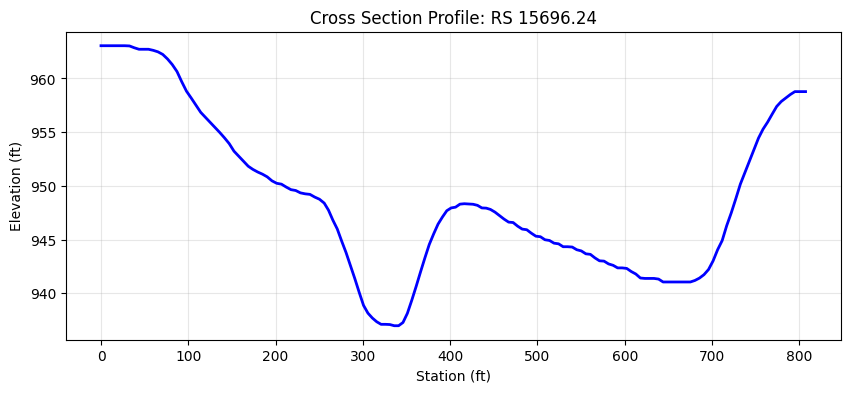

In [6]:
# Get first cross section
first_rs = xyz['RS'].unique()[0]

xyz_single = GeomCrossSection.get_xs_coords(
    geom_file,
    river=rivers[0],
    reach=reaches[0],
    rs=first_rs
)

print(f"Cross section RS {first_rs}:")
print(f"  Points: {len(xyz_single)}")
print(f"  Station range: {xyz_single['station'].min():.2f} to {xyz_single['station'].max():.2f}")
print(f"  Elevation range: {xyz_single['z'].min():.2f} to {xyz_single['z'].max():.2f} ft")

# Show profile
plt.figure(figsize=(10, 4))
plt.plot(xyz_single['station'], xyz_single['z'], 'b-', linewidth=2)
plt.xlabel('Station (ft)')
plt.ylabel('Elevation (ft)')
plt.title(f'Cross Section Profile: RS {first_rs}')
plt.grid(True, alpha=0.3)
plt.show()

## Example 4: Export to Shapefile

Convert XYZ coordinates to GIS LineStrings and export to shapefile.

In [7]:
# Convert to LineStrings (one per cross section)
xs_lines = []

for (river, reach, rs), group in xyz.groupby(['river', 'reach', 'RS']):
    # Create 3D LineString from XYZ coordinates
    coords = list(zip(group['x'], group['y'], group['z']))
    
    xs_lines.append({
        'river': river,
        'reach': reach,
        'RS': rs,
        'num_points': len(coords),
        'min_elev': group['z'].min(),
        'max_elev': group['z'].max(),
        'geometry': LineString(coords)
    })

gdf = gpd.GeoDataFrame(xs_lines, geometry='geometry')
print(f"Created GeoDataFrame with {len(gdf)} cross sections")
print(f"\nFirst 3 cross sections:")
gdf[['river', 'reach', 'RS', 'num_points', 'min_elev', 'max_elev']].head(3)

Created GeoDataFrame with 61 cross sections

First 3 cross sections:


,river,reach,RS,num_points,min_elev,max_elev
0,White,Muncie,10216.27,40,932.24,946.35
1,White,Muncie,10672.75,50,931.58,946.32
2,White,Muncie,11188.16,45,932.90,946.12


In [8]:
# Set coordinate reference system (UTM Zone 16N for Indiana)
gdf_utm = gdf.set_crs(epsg=26916)

# Export to shapefile
output_path = project_path / "cross_sections_xyz.shp"
gdf_utm.to_file(output_path)

print(f"Exported to: {output_path}")
print(f"\nShapefile includes:")
print(f"  - 3D LineString geometries (XYZ)")
print(f"  - River/Reach/RS attributes")
print(f"  - Number of points per XS")
print(f"  - Min/max elevation per XS")

2026-02-28 13:21:07 - pyogrio._io - INFO - Created 61 records


Exported to: C:\GH\ras-commander\examples\example_projects\Muncie_xs_coords_demo\cross_sections_xyz.shp

Shapefile includes:
  - 3D LineString geometries (XYZ)
  - River/Reach/RS attributes
  - Number of points per XS
  - Min/max elevation per XS


## Example 5: Visualize Cross Sections in Plan View

Plot cross section locations colored by minimum elevation.

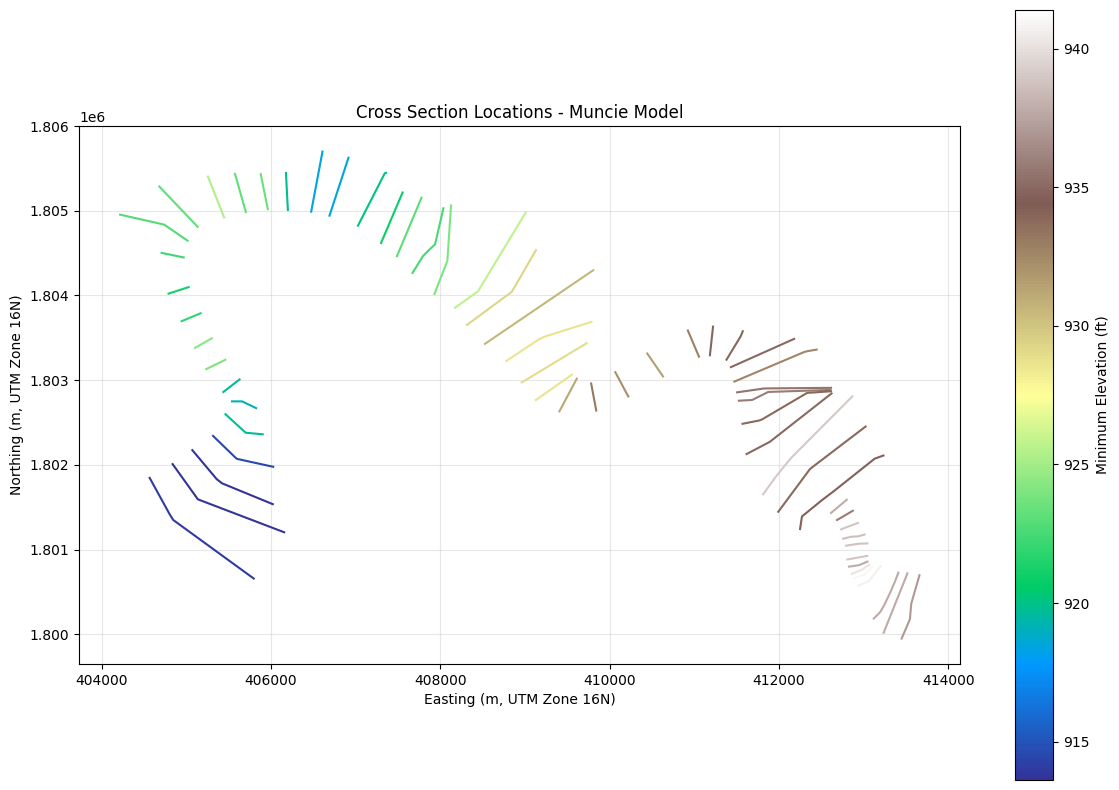

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each cross section colored by min elevation
gdf_utm.plot(ax=ax, column='min_elev', cmap='terrain', legend=True,
             legend_kwds={'label': 'Minimum Elevation (ft)'})

plt.xlabel('Easting (m, UTM Zone 16N)')
plt.ylabel('Northing (m, UTM Zone 16N)')
plt.title('Cross Section Locations - Muncie Model')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Regression Validation: Cut Line Parsing with Many Points

These cells validate the fix for a bug where `get_xs_cut_lines()` failed on cross
sections with many cut line points (84+ points). The root cause was that HEC-RAS
geometry files use 16-character fixed-width FORTRAN format, and when coordinate values
fill all 16 characters, adjacent values concatenate without whitespace separators.

**What we test:**
1. Multi-project completeness â€” parse ALL cut lines from Muncie and Bald Eagle Creek
2. Synthetic stress test â€” programmatically create a geometry file with 150 cut line
   points using values that cause 16-char field overflow (the actual bug trigger)
3. Summary across all tested projects

In [10]:
# Validation 1: Multi-project cut line completeness
# Verify ALL XS with GIS Cut Lines produce correct coordinates across multiple projects

test_projects = {
    'Muncie': geom_file,  # Already extracted above
}

# Extract Bald Eagle Creek (1D version, 178 XS)
bec_path = RasExamples.extract_project("Balde Eagle Creek", suffix="205_validation")
bec_geoms = list(bec_path.glob("*.g0*"))
if bec_geoms:
    test_projects['Balde Eagle Creek'] = bec_geoms[0]
    print(f"Bald Eagle Creek geometry: {bec_geoms[0].name}")

total_tested = 0
total_passed = 0

for proj_name, gf in test_projects.items():
    geom_text = gf.read_text()
    geom_lines_list = geom_text.splitlines()

    # Count declared cut lines from geometry file
    expected = {}
    current_station = None
    for line in geom_lines_list:
        s = line.strip()
        if s.startswith('Type RM Length L Ch R'):
            parts = s.split('=')[1].strip().split(',')
            if len(parts) >= 2:
                current_station = parts[1].strip()
        elif s.startswith('XS GIS Cut Line=') and current_station:
            expected[current_station] = int(s.split('=')[1])

    # Parse with GeomParser
    cut_lines_gdf = GeomParser.get_xs_cut_lines(gf)

    # Check completeness
    parsed_stations = set(cut_lines_gdf['station'].astype(str))
    expected_stations = set(expected.keys())
    missing = expected_stations - parsed_stations

    # Check point counts
    mismatches = []
    for _, row in cut_lines_gdf.iterrows():
        station = str(row['station'])
        actual_pts = len(row['geometry'].coords)
        expected_pts = expected.get(station)
        if expected_pts and actual_pts != expected_pts:
            mismatches.append(f"  RS {station}: expected {expected_pts}, got {actual_pts}")

    max_pts = max(expected.values()) if expected else 0
    status = "PASS" if (not missing and not mismatches) else "FAIL"
    total_tested += len(expected)
    total_passed += len(expected) - len(missing) - len(mismatches)

    print(f"\n{proj_name}: {status}")
    print(f"  XS with cut lines: {len(expected)}")
    print(f"  Max cut line points: {max_pts}")
    print(f"  Missing from parse: {len(missing)}")
    print(f"  Point count mismatches: {len(mismatches)}")

    if missing:
        for station in sorted(missing):
            print(f"  MISSING: RS {station} ({expected[station]} points)")
    if mismatches:
        for m in mismatches[:5]:
            print(m)

    assert len(missing) == 0, f"{proj_name}: {len(missing)} XS dropped during parsing"
    assert len(mismatches) == 0, f"{proj_name}: {len(mismatches)} point count mismatches"

print(f"\nMulti-project validation: {total_passed}/{total_tested} cut lines PASSED")

2026-02-28 13:21:07 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-02-28 13:21:07 - ras_commander.RasExamples - INFO - Extracting project 'Balde Eagle Creek' as 'Balde Eagle Creek_205_validation'


2026-02-28 13:21:07 - ras_commander.RasExamples - INFO - Folder 'Balde Eagle Creek_205_validation' already exists. Deleting existing folder...


2026-02-28 13:21:07 - ras_commander.RasExamples - INFO - Existing folder 'Balde Eagle Creek_205_validation' has been deleted.


2026-02-28 13:21:07 - ras_commander.RasExamples - INFO - Successfully extracted project 'Balde Eagle Creek' to C:\GH\ras-commander\examples\example_projects\Balde Eagle Creek_205_validation


2026-02-28 13:21:07 - ras_commander.geom.GeomParser - INFO - Extracting XS cut lines from: C:\GH\ras-commander\examples\example_projects\Muncie_xs_coords_demo\Muncie.g01


2026-02-28 13:21:07 - ras_commander.geom.GeomParser - INFO - Found 61 XS cut lines


2026-02-28 13:21:07 - ras_commander.geom.GeomParser - INFO - Extracting XS cut lines from: C:\GH\ras-commander\examples\example_projects\Balde Eagle Creek_205_validation\BaldEagle.g01


2026-02-28 13:21:07 - ras_commander.geom.GeomParser - INFO - Found 178 XS cut lines


Bald Eagle Creek geometry: BaldEagle.g01

Muncie: PASS
  XS with cut lines: 61
  Max cut line points: 6
  Missing from parse: 0
  Point count mismatches: 0

Balde Eagle Creek: PASS
  XS with cut lines: 178
  Max cut line points: 5
  Missing from parse: 0
  Point count mismatches: 0

Multi-project validation: 239/239 cut lines PASSED


In [11]:
# Validation 2: Synthetic stress test with 150 cut line points
# This exercises the ACTUAL BUG: 16-char fixed-width field overflow causes
# adjacent coordinate values to concatenate without whitespace separators.
#
# Example of the bug trigger (16-char columns, no whitespace between values):
#   "3101220.584826113779229.7976261" = two values concatenated
#   vs normal: "   3101220.5848  13779229.7976" = same values with whitespace
#
# The hybrid parser must detect and correctly split these concatenated values.

import tempfile
import numpy as np

NUM_POINTS = 150  # Well above the 84-point threshold that triggered the original bug

# Generate coordinates that FILL all 16 characters (causes concatenation)
# Use realistic UTM-scale coordinates (7-digit easting, 8-digit northing)
np.random.seed(42)
base_x = 3101220.0  # Large easting (fills 16 chars with decimals)
base_y = 13779229.0  # Large northing (fills 16 chars with decimals)

xs = base_x + np.cumsum(np.random.uniform(0.5, 2.0, NUM_POINTS))
ys = base_y + np.cumsum(np.random.uniform(-1.0, 1.0, NUM_POINTS))

# Format as 16-char fixed-width (FORTRAN style) - values will concatenate
total_values = NUM_POINTS * 2
data_lines = []
vals = []
for i in range(NUM_POINTS):
    vals.append(f"{xs[i]:16.7f}")  # Fills all 16 chars
    vals.append(f"{ys[i]:16.7f}")  # Fills all 16 chars

# Pack 10 values per line (standard HEC-RAS format)
for i in range(0, len(vals), 10):
    chunk = vals[i:i+10]
    data_lines.append("".join(chunk))  # No whitespace between values!

# Build minimal geometry file with this cut line
synthetic_geom = f"""Geom Title=Synthetic Test
Program Version=6.50
River Reach=TestRiver    ,TestReach
Reach XY= 2
         0.00         0.00
     10000.00         0.00
Type RM Length L Ch R = 1 ,5000.000,     0.0,     0.0,     0.0
Node Last Edited Time=Jan/01/2025 00:00:00
#Sta/Elev= 3
     0.0  100.0  500.0  100.0 1000.0  100.0
#Mann= 2 , 0 , 0
     0   .04     0     0 500   .04     0     0
Bank Sta=0,1000
XS GIS Cut Line={NUM_POINTS}
"""
synthetic_geom += "\n".join(data_lines) + "\n"

# Write to temp file
with tempfile.NamedTemporaryFile(mode='w', suffix='.g01', delete=False, dir=str(project_path)) as f:
    f.write(synthetic_geom)
    synthetic_file = Path(f.name)

print(f"Created synthetic geometry: {synthetic_file.name}")
print(f"  Cut line points: {NUM_POINTS}")
print(f"  Total coordinate values: {total_values}")
print(f"  Data lines: {len(data_lines)}")

# Show first data line to demonstrate concatenation
print(f"\n  First data line (note: NO whitespace between 16-char values):")
print(f"  '{data_lines[0][:80]}...'")

# Parse with GeomParser
try:
    result_gdf = GeomParser.get_xs_cut_lines(synthetic_file)

    if len(result_gdf) == 0:
        print("\nFAIL: No cut lines parsed from synthetic file")
        assert False, "Synthetic cut line not parsed"

    parsed_points = len(result_gdf.iloc[0]['geometry'].coords)

    print(f"\n  Parsed points: {parsed_points}")
    print(f"  Expected points: {NUM_POINTS}")

    if parsed_points == NUM_POINTS:
        # Verify coordinate accuracy
        parsed_coords = list(result_gdf.iloc[0]['geometry'].coords)
        max_x_error = max(abs(parsed_coords[i][0] - xs[i]) for i in range(NUM_POINTS))
        max_y_error = max(abs(parsed_coords[i][1] - ys[i]) for i in range(NUM_POINTS))

        print(f"  Max X error: {max_x_error:.10f}")
        print(f"  Max Y error: {max_y_error:.10f}")
        print(f"\nPASS: All {NUM_POINTS} cut line points parsed correctly from concatenated 16-char format")
    else:
        print(f"\nFAIL: Expected {NUM_POINTS} points, got {parsed_points}")
        assert False, f"Point count mismatch: {parsed_points} != {NUM_POINTS}"

    assert parsed_points == NUM_POINTS, f"Parsed {parsed_points} points, expected {NUM_POINTS}"
    assert max_x_error < 1e-4, f"X coordinate error too large: {max_x_error}"
    assert max_y_error < 1e-4, f"Y coordinate error too large: {max_y_error}"

finally:
    # Clean up synthetic file
    synthetic_file.unlink(missing_ok=True)

2026-02-28 13:21:08 - ras_commander.geom.GeomParser - INFO - Extracting XS cut lines from: C:\GH\ras-commander\examples\example_projects\Muncie_xs_coords_demo\tmpr_jmg1e3.g01


2026-02-28 13:21:08 - ras_commander.geom.GeomParser - INFO - Found 1 XS cut lines


Created synthetic geometry: tmpr_jmg1e3.g01
  Cut line points: 150
  Total coordinate values: 300
  Data lines: 30

  First data line (note: NO whitespace between 16-char values):
  ' 3101221.061810213779229.8165318 3101222.987881613779229.2956556 3101224.5858726...'

  Parsed points: 150
  Expected points: 150
  Max X error: 0.0000000498
  Max Y error: 0.0000000484

PASS: All 150 cut line points parsed correctly from concatenated 16-char format


## Regression Validation 3: Dynamic Section Search for Station-Elevation Lookup

When a cross section has many GIS cut line points, the data between the XS header
(`Type RM Length L Ch R =`) and `#Sta/Elev=` can span hundreds of lines.

**Bug history**:
- `DEFAULT_SEARCH_RANGE` was 50 lines, then increased to 500
- Now replaced with dynamic `_find_xs_section_end()` that searches to the end of
  the current XS section regardless of length

**This test** uses 600 cut line points (producing ~300 data lines) to prove there
is no fixed limit on the search range.

In [12]:
# Validation 3: Dynamic section search regression test
# Verify get_station_elevation() can find #Sta/Elev= past large cut line data blocks
#
# Previously DEFAULT_SEARCH_RANGE was 50 (then 500), now replaced with dynamic
# _find_xs_section_end() that has no fixed limit. This test uses 600 cut line
# points to prove the parser handles arbitrarily large cut line sections.

import tempfile

NUM_SEARCH_TEST_POINTS = 600  # Well beyond any fixed limit (proves dynamic search)

# Generate cut line coordinate values
np.random.seed(99)
search_xs = 3101220.0 + np.cumsum(np.random.uniform(0.5, 2.0, NUM_SEARCH_TEST_POINTS))
search_ys = 13779229.0 + np.cumsum(np.random.uniform(-1.0, 1.0, NUM_SEARCH_TEST_POINTS))

# Format as 16-char fixed-width, 10 values per line
search_vals = []
for i in range(NUM_SEARCH_TEST_POINTS):
    search_vals.append(f"{search_xs[i]:16.7f}")
    search_vals.append(f"{search_ys[i]:16.7f}")

search_data_lines = []
for i in range(0, len(search_vals), 10):
    chunk = search_vals[i:i+10]
    search_data_lines.append("".join(chunk))

num_cut_data_lines = len(search_data_lines)
print(f"Cut line: {NUM_SEARCH_TEST_POINTS} points -> {num_cut_data_lines} data lines")
print(f"Old DEFAULT_SEARCH_RANGE was 50 (then 500) -> both would MISS #Sta/Elev=")
print(f"Dynamic _find_xs_section_end() searches to end of XS section -> no limit")

# Build geometry with cut line data BEFORE #Sta/Elev= (realistic structure)
search_geom = f"""Geom Title=Search Range Regression Test
Program Version=6.50
River Reach=TestRiver    ,TestReach
Reach XY= 2
         0.00         0.00
     10000.00         0.00
Type RM Length L Ch R = 1 ,5000.000,     0.0,     0.0,     0.0
Node Last Edited Time=Jan/01/2025 00:00:00
Bank Sta=0,1000
XS GIS Cut Line={NUM_SEARCH_TEST_POINTS}
"""
search_geom += "\n".join(search_data_lines) + "\n"
search_geom += """Node Name=
Dist XS Type=
#Sta/Elev= 5
    0.00  100.00  250.00   95.00  500.00   90.00  750.00   95.00 1000.00  100.00
#Mann= 2 , 0 , 0
     0   .04     0     0 500   .04     0     0
"""

with tempfile.NamedTemporaryFile(mode='w', suffix='.g01', delete=False, dir=str(project_path)) as f:
    f.write(search_geom)
    search_test_file = Path(f.name)

try:
    # This is the critical test: can get_station_elevation() find #Sta/Elev=
    # past all the cut line data?
    sta_elev_df = GeomCrossSection.get_station_elevation(
        search_test_file, "TestRiver", "TestReach", "5000.000"
    )

    assert sta_elev_df is not None, \
        "get_station_elevation() returned None -- dynamic section search failed!"
    assert len(sta_elev_df) == 5, \
        f"Expected 5 station-elevation pairs, got {len(sta_elev_df)}"

    # Verify values are correct
    assert abs(sta_elev_df.iloc[0]['Station'] - 0.0) < 0.01
    assert abs(sta_elev_df.iloc[0]['Elevation'] - 100.0) < 0.01
    assert abs(sta_elev_df.iloc[2]['Station'] - 500.0) < 0.01
    assert abs(sta_elev_df.iloc[2]['Elevation'] - 90.0) < 0.01

    print(f"\nPASS: get_station_elevation() found #Sta/Elev= past {NUM_SEARCH_TEST_POINTS} "
          f"cut line points ({num_cut_data_lines} data lines)")
    print(f"  Station-elevation pairs extracted: {len(sta_elev_df)}")
    print(f"  First pair: station={sta_elev_df.iloc[0]['Station']}, elev={sta_elev_df.iloc[0]['Elevation']}")
    print(f"  Last pair:  station={sta_elev_df.iloc[-1]['Station']}, elev={sta_elev_df.iloc[-1]['Elevation']}")
    search_range_passed = True

finally:
    search_test_file.unlink(missing_ok=True)

2026-02-28 13:21:08 - ras_commander.geom.GeomCrossSection - INFO - Extracted 5 station/elevation pairs for TestRiver/TestReach/RS 5000.000


Cut line: 600 points -> 120 data lines
Old DEFAULT_SEARCH_RANGE was 50 (then 500) -> both would MISS #Sta/Elev=
Dynamic _find_xs_section_end() searches to end of XS section -> no limit

PASS: get_station_elevation() found #Sta/Elev= past 600 cut line points (120 data lines)
  Station-elevation pairs extracted: 5
  First pair: station=0.0, elev=100.0
  Last pair:  station=1000.0, elev=100.0


In [13]:
# Validation Summary
print("=" * 60)
print("REGRESSION VALIDATION SUMMARY")
print("=" * 60)
print()
print("Validation 1: Multi-project cut line completeness")
print(f"  Projects tested: {', '.join(test_projects.keys())}")
print(f"  Total cut lines: {total_tested}")
print(f"  All passed: {total_passed}/{total_tested}")
print()
print("Validation 2: Synthetic 150-point stress test (cut line parsing)")
print(f"  Cut line points: {NUM_POINTS}")
print(f"  16-char field overflow: verified (concatenated values)")
print(f"  Coordinate accuracy: < 1e-4")
print()
print("Validation 3: Dynamic section search (station-elevation lookup)")
print(f"  Cut line points before #Sta/Elev=: {NUM_SEARCH_TEST_POINTS}")
print(f"  Cut line data lines: {num_cut_data_lines} (old fixed limits: 50, then 500)")
print(f"  Dynamic _find_xs_section_end(): {'PASS' if search_range_passed else 'FAIL'}")
print()
print("All regression validations PASSED")

REGRESSION VALIDATION SUMMARY

Validation 1: Multi-project cut line completeness
  Projects tested: Muncie, Balde Eagle Creek
  Total cut lines: 239
  All passed: 239/239

Validation 2: Synthetic 150-point stress test (cut line parsing)
  Cut line points: 150
  16-char field overflow: verified (concatenated values)
  Coordinate accuracy: < 1e-4

Validation 3: Dynamic section search (station-elevation lookup)
  Cut line points before #Sta/Elev=: 600
  Cut line data lines: 120 (old fixed limits: 50, then 500)
  Dynamic _find_xs_section_end(): PASS

All regression validations PASSED


## Example 6: Batch Processing Multiple Models

Extract XYZ from multiple geometry files.

In [14]:
# Example: Process multiple geometry files
# (In this demo we'll just use different extractions of the same project)

models = [
    {'name': 'Muncie_Model1', 'project': 'Muncie'},
    {'name': 'Muncie_Model2', 'project': 'Muncie'},
]

all_xyz = []

for model in models:
    # Extract project
    path = RasExamples.extract_project(model['project'], suffix=model['name'])
    geom = list(path.glob("*.g0*"))[0]
    
    # Extract XYZ
    xyz_model = GeomCrossSection.get_xs_coords(geom)
    xyz_model['model_name'] = model['name']
    
    all_xyz.append(xyz_model)
    
    print(f"{model['name']:20s}: {len(xyz_model):5,} points, {xyz_model['RS'].nunique():3d} XS")

# Combine all models
combined = pd.concat(all_xyz, ignore_index=True)

print(f"\nTotal: {len(combined):,} points from {combined['model_name'].nunique()} models")

2026-02-28 13:21:08 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-02-28 13:21:08 - ras_commander.RasExamples - INFO - Extracting project 'Muncie' as 'Muncie_Muncie_Model1'


2026-02-28 13:21:08 - ras_commander.RasExamples - INFO - Folder 'Muncie_Muncie_Model1' already exists. Deleting existing folder...


2026-02-28 13:21:08 - ras_commander.RasExamples - INFO - Existing folder 'Muncie_Muncie_Model1' has been deleted.


2026-02-28 13:21:08 - ras_commander.RasExamples - INFO - Successfully extracted project 'Muncie' to C:\GH\ras-commander\examples\example_projects\Muncie_Muncie_Model1


...

2026-02-28 13:21:09 - ras_commander.geom.GeomCrossSection - INFO - Extracted 116 station/elevation pairs for White/Muncie/RS 865.5413


2026-02-28 13:21:09 - ras_commander.geom.GeomCrossSection - INFO - Extracted 156 station/elevation pairs for White/Muncie/RS 570.1187


2026-02-28 13:21:09 - ras_commander.geom.GeomCrossSection - INFO - Extracted 135 station/elevation pairs for White/Muncie/RS 237.6455


2026-02-28 13:21:09 - ras_commander.geom.GeomCrossSection - INFO - Extracted 5158 XYZ points from 61 cross sections


Muncie_Model2       : 5,158 points,  61 XS

Total: 10,316 points from 2 models
